# Class 10: Transfer Learning

Today we will:
- Explore what **pre-trained models** already know
- **Fine-tune** a large model for a custom task with very little data
- Connect to the broader **foundation model** paradigm

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from os import path
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Lambda,
    Input, Rescaling, Reshape, GlobalAveragePooling2D,
    RandomRotation, RandomZoom
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.resnet50 import ResNet50, decode_predictions, preprocess_input
from tensorflow.keras.utils import load_img, img_to_array, image_dataset_from_directory

prng = np.random.RandomState(20260318)
tf.random.set_seed(20260318)

%precision 3
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [ ]:
class ResultCollector:
    def __init__(self):
        self.results = {}

    def add_model(self, name, train_acc, test_acc):
        """Add or update a model's results."""
        self.results[name] = {
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Gap': train_acc - test_acc
        }
        return self.get_table()

    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        if style:
            return df.style.format("{:.4f}", subset=['Train Accuracy', 'Test Accuracy', 'Gap']) \
                .background_gradient(cmap='RdYlGn', subset=['Test Accuracy'], axis=None)
        return df

results = ResultCollector()

In [35]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation loss/accuracy from a Keras history object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'], label='Train')
    ax2.plot(history.history['val_accuracy'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

## [Optional material, skipped in class] Data Augmentation: Manufacturing Training Data

In Class 9, we achieved ~99% on MNIST with 30K images. But what if we only had 1,000? Or 500?

Collecting real data is expensive. **Data augmentation** creates new training examples by applying semantically valid transformations to existing data: a slightly rotated digit is still the same digit.

**Connection to Class 4:** Augmentation reduces variance (model sees more diverse examples) without increasing bias (transformed digits are still valid digits). It's regularization for free. Similar idea to bootstrapping but better.

### Load MNIST and create a small subset

We'll simulate a data-scarce scenario by using only 1,000 training images.

In [36]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Small subset: simulate data scarcity
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=1000, random_state=20260318, stratify=y_train_full
)

print(f"Small training set: {X_train_small.shape}")
print(f"Test set: {X_test.shape}")

Small training set: (1000, 28, 28)
Test set: (10000, 28, 28)


### Baseline: CNN on the small subset (no augmentation)

Let's train the same CNN architecture from Class 9 on our small dataset. We expect significant overfitting — the model has enough capacity to memorize 1,000 images.

In [37]:
# Preprocessing: reshape to (28,28,1) and scale to [0,1]
preprocess = Sequential([
    Input(shape=(28, 28)),
    Reshape(target_shape=(28, 28, 1)),
    Rescaling(1./255)
])

In [38]:
cnn_layers = Sequential([
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model_no_aug = Sequential([preprocess, cnn_layers])

model_no_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_aug = model_no_aug.fit(
    X_train_small, y_train_small,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

train_loss, train_acc = model_no_aug.evaluate(X_train_small, y_train_small, verbose=0)
test_loss, test_acc = model_no_aug.evaluate(X_test, y_test, verbose=0)

results.add_model('CNN (1K, no augmentation)', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
"CNN (1K, no augmentation)",1.0000,0.9488,0.0512


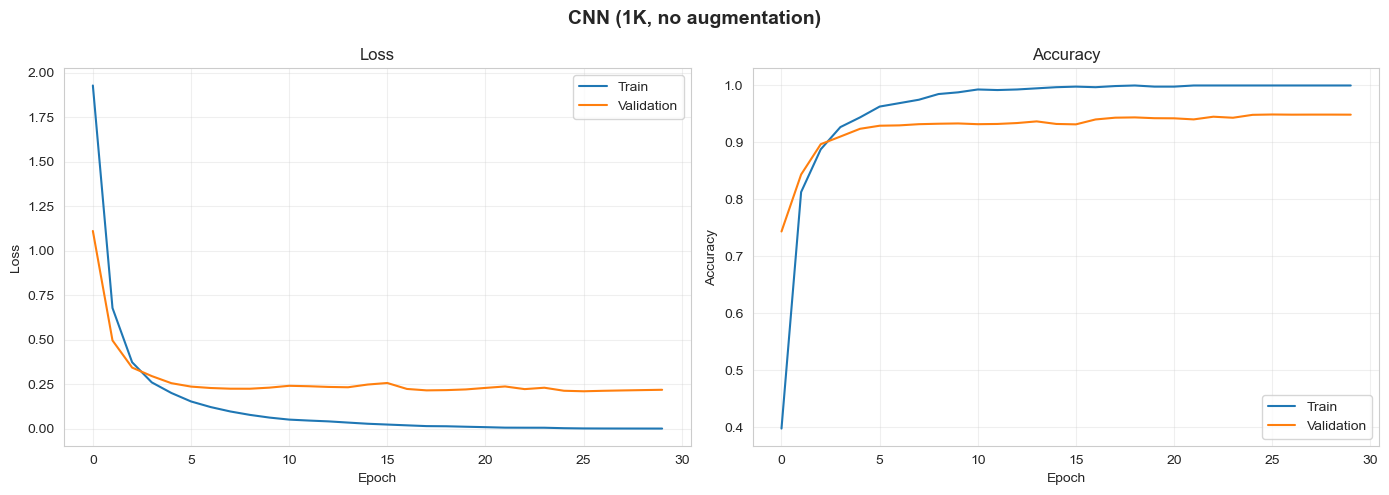

In [39]:
plot_training_history(history_no_aug, "CNN (1K, no augmentation)")

As expected: the model quickly memorizes the small training set (training accuracy near 100%) while validation accuracy lags behind. The gap is a clear sign of overfitting.

We need more data, but collecting real labeled data is expensive. What if we could **create** more data?

### The key insight: transformed digits are still digits

A slightly rotated "3" is still a "3". A slightly zoomed "7" is still a "7". We can exploit this by applying random transformations during training -> each epoch sees slightly different versions of the same images.

In [40]:
data_augmentation = Sequential([
    RandomRotation(0.1, fill_mode="nearest"),
    RandomZoom(0.1, fill_mode="nearest")
])

### Visualize augmented images

Top row: original digits. Bottom row: augmented versions. The transformations are subtle — enough to create diversity but not enough to change the digit class.

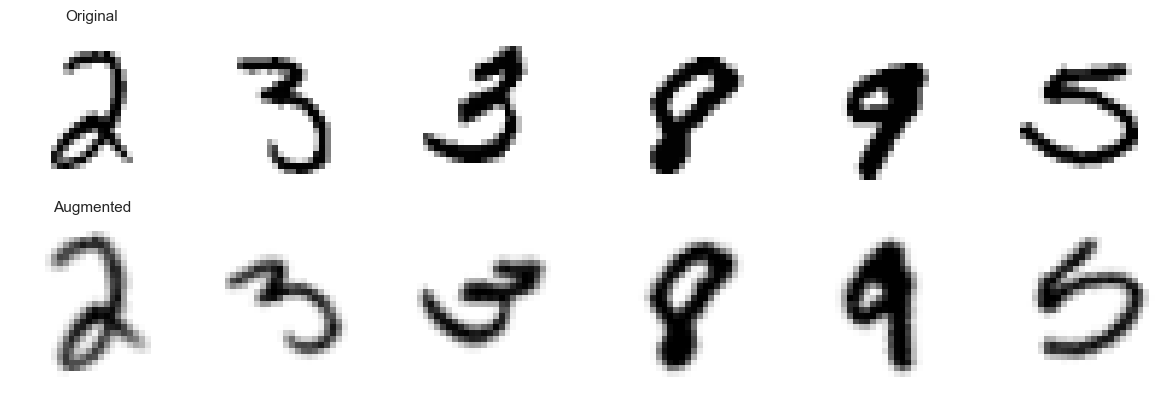

In [41]:
n_digits = 6
sample_images = X_train_small[:n_digits]

preprocessed = preprocess(sample_images)
augmented = data_augmentation(preprocessed)

fig, axs = plt.subplots(2, n_digits, figsize=(2 * n_digits, 4))

for i in range(n_digits):
    axs[0, i].imshow(preprocessed[i], cmap='binary')
    axs[0, i].axis('off')
    if i == 0:
        axs[0, i].set_title('Original', fontsize=11)

    axs[1, i].imshow(augmented[i], cmap='binary')
    axs[1, i].axis('off')
    if i == 0:
        axs[1, i].set_title('Augmented', fontsize=11)

plt.tight_layout()
plt.show()

### Train CNN with augmentation

We insert the augmentation layers between preprocessing and the CNN. These layers are only active during training — at test time, images pass through unchanged.

In [42]:
# Rebuild CNN layers (weights are reset) — same architecture, only augmentation differs
cnn_layers_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model_with_aug = Sequential([
    preprocess,
    data_augmentation,
    cnn_layers_aug
])

model_with_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_with_aug = model_with_aug.fit(
    X_train_small, y_train_small,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

train_loss, train_acc = model_with_aug.evaluate(X_train_small, y_train_small, verbose=0)
test_loss, test_acc = model_with_aug.evaluate(X_test, y_test, verbose=0)

results.add_model('CNN (1K, with augmentation)', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
"CNN (1K, no augmentation)",1.0000,0.9488,0.0512
"CNN (1K, with augmentation)",0.9870,0.9522,0.0348


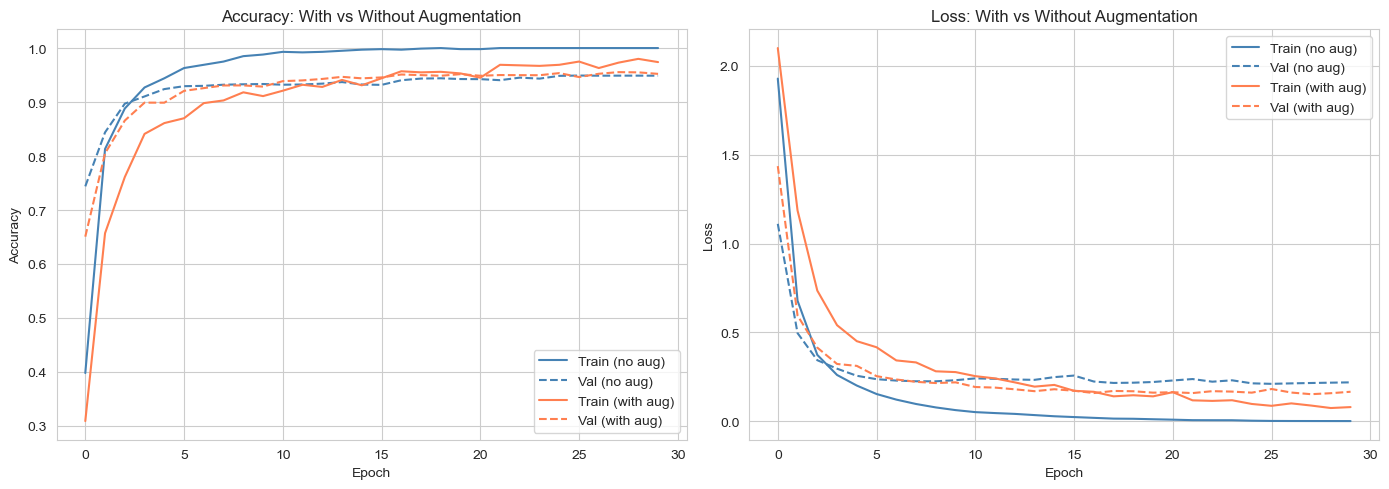

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_aug.history['accuracy'], label='Train (no aug)', color='steelblue')
axes[0].plot(history_no_aug.history['val_accuracy'], label='Val (no aug)', color='steelblue', linestyle='--')
axes[0].plot(history_with_aug.history['accuracy'], label='Train (with aug)', color='coral')
axes[0].plot(history_with_aug.history['val_accuracy'], label='Val (with aug)', color='coral', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: With vs Without Augmentation')
axes[0].legend()

axes[1].plot(history_no_aug.history['loss'], label='Train (no aug)', color='steelblue')
axes[1].plot(history_no_aug.history['val_loss'], label='Val (no aug)', color='steelblue', linestyle='--')
axes[1].plot(history_with_aug.history['loss'], label='Train (with aug)', color='coral')
axes[1].plot(history_with_aug.history['val_loss'], label='Val (with aug)', color='coral', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: With vs Without Augmentation')
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
results.get_table()

,Train Accuracy,Test Accuracy,Gap
"CNN (1K, no augmentation)",1.0000,0.9488,0.0512
"CNN (1K, with augmentation)",0.9870,0.9522,0.0348


**Observations:**
- Without augmentation: training accuracy shoots to ~100%, validation accuracy plateaus lower (overfitting)
- With augmentation: training accuracy is lower (the model sees harder examples), but validation accuracy is higher (better generalization)
- The train-test gap shrinks -> augmentation acts as regularization, just as we predicted from the Class 4 framework

Data augmentation is essentially free regularization: it increases the effective dataset size without collecting new data.

### When does augmentation help most?

| Scenario | Impact |
|---|---|
| **Small datasets** | Biggest impact — reduces variance (Class 4) by exposing the model to more diverse examples |
| **Semantically valid transforms** | Rotated digit = still a digit → no increase in bias |
| **Very large datasets** | Less impact (already enough diversity) |
| **Invalid transforms** | Can hurt! (flipped text, inverted medical images) → increases bias |

*Question:* Why might horizontal flipping be a valid augmentation for animal photos but not for digit recognition?

<details>
<summary>Answer</summary>

A horizontally flipped cat is still a cat. But a horizontally flipped "6" looks like a "backwards 6" which doesn't appear in real handwritten data. The augmentation must preserve the meaning of the label.

</details>

## Motivation for Transfer Learning

Data augmentation helps, but what about tasks where you have only 200 images of a custom category? No amount of rotation fixes that.

And even if you had enough data, training a serious CNN from scratch (like ResNet: 50 layers, 25M parameters) requires millions of images and days of GPU training.

**The key insight:** Early CNN layers learn **universal features** (edges, textures) while later layers learn task-specific features. The hidden layers transform raw pixels into meaningful features. These universal features are **reusable** across tasks.

Think of it this way: you learned to read in school. When you pick up a new textbook, you don't re-learn the alphabet.

## Pre-trained Models in Action

Let's see what a model trained on 1.2 million images across 1,000 categories already knows.

### Load ResNet50 pre-trained on ImageNet

In [45]:
pretrained_model = ResNet50(weights='imagenet')

In [46]:
pretrained_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_16[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

25M+ parameters, trained on ImageNet for days on GPUs. The non-trainable parameters come from batch normalization layers that track running statistics.

### Predict on some images

Let's feed some images to ResNet50 and see what it thinks. We define a helper function that loads an image from a URL, preprocesses it, and shows the top-3 predictions.

In [47]:
import urllib.request
import tempfile

def predict_from_url(url, model=pretrained_model):
    """Load an image from URL, predict with ResNet50, and display."""
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=10) as response:
            with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
                tmp.write(response.read())
                img_path = tmp.name
    except Exception as e:
        print(f"Could not fetch image: {e}")
        return

    img = load_img(img_path, target_size=(224, 224))

    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x, verbose=0)
    decoded = decode_predictions(preds, top=3)[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    title_lines = [f"{name}: {prob:.1%}" for (_, name, prob) in decoded]
    plt.title('\n'.join(title_lines), fontsize=11)
    plt.tight_layout()
    plt.show()

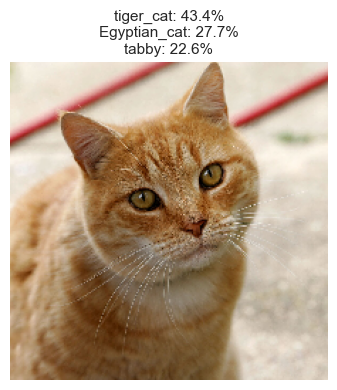

In [48]:
predict_from_url("https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg")

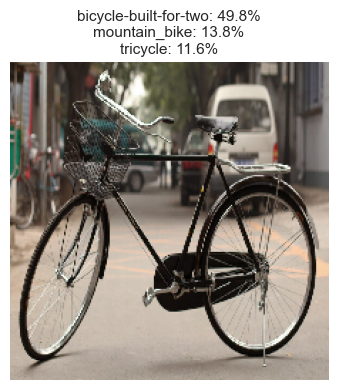

In [49]:
predict_from_url("https://upload.wikimedia.org/wikipedia/commons/thumb/4/41/Left_side_of_Flying_Pigeon.jpg/1200px-Left_side_of_Flying_Pigeon.jpg")

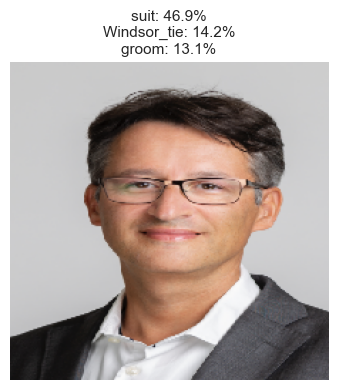

In [50]:
predict_from_url("https://economics.ceu.edu/sites/economics.ceu.edu/files/styles/profile_teaser/public/screenshot2021-10-05at095428_4.png?itok=XXh4uqAW")

The model already knows cats, bicycles, and 998 other categories. But what if our task isn't one of the 1,000 ImageNet classes?

*Question:* If we want to classify images of a completely new category (say, types of skin lesions), do we need to train a 25M-parameter model from scratch?

<details>
<summary>Answer</summary>

No! The early layers of ResNet already know how to detect edges, textures, and shapes. We can **reuse** those learned features and only train a small classification head for our new task. This is transfer learning.

</details>

## Transfer Learning: Hot Dog vs Not Hot Dog

Inspired by [HBO's Silicon Valley](https://youtu.be/vIci3C4JkL0): a fun, memorable binary classification task.

Download the data from [Kaggle](https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog) and place it in `../data/hotdog/`.

### Load the hot dog dataset

In [51]:
data_dir = "../data/hotdog/"
img_size = (224, 224)

if not path.exists(path.join(data_dir, "train")):
    raise FileNotFoundError(
        "Hot dog dataset not found. Download from:\n"
        "https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog\n"
        "Extract to ../data/hotdog/ with train/ and test/ subdirectories."
    )

train_dataset = image_dataset_from_directory(
    path.join(data_dir, "train"),
    batch_size=32,
    image_size=img_size,
    seed=20260318
)

test_dataset = image_dataset_from_directory(
    path.join(data_dir, "test"),
    batch_size=32,
    image_size=img_size,
    seed=20260318
)

print(f"Classes: {train_dataset.class_names}")

Found 498 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Classes: ['hot_dog', 'not_hot_dog']


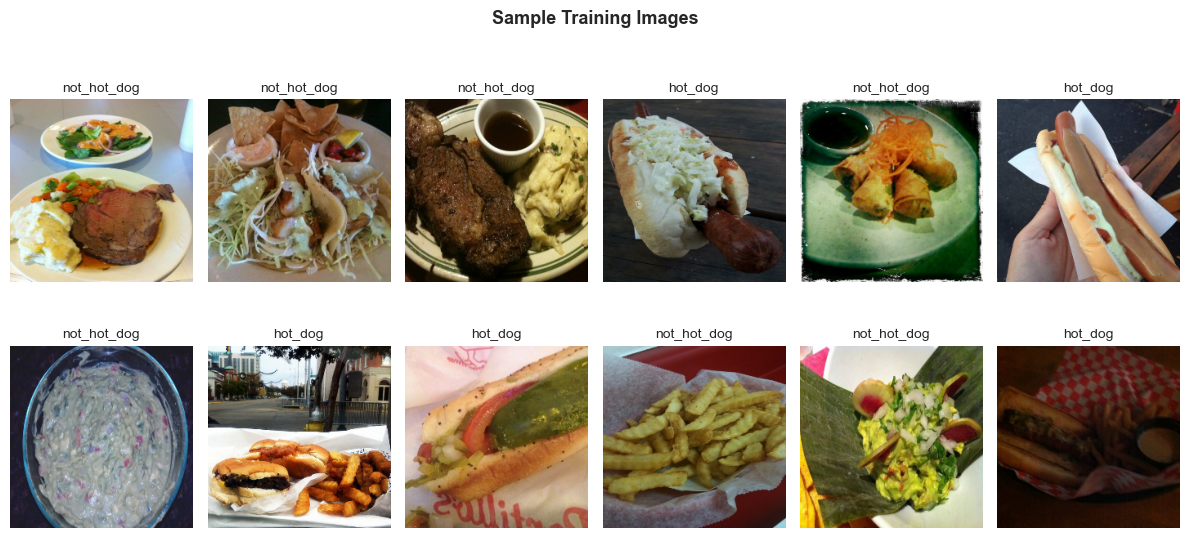

In [52]:
plt.figure(figsize=(12, 6))
for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(train_dataset.class_names[labels[i]], fontsize=10)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What does the pre-trained model think?

Before any fine-tuning, let's see how the original ImageNet-trained ResNet50 handles our hot dog images. It knows "hotdog" as one of its 1,000 classes, but let's see how confident it is.

In [53]:
for images, labels in train_dataset.take(1):
    # Pick one hot_dog and one not_hot_dog
    for label_val, label_name in enumerate(train_dataset.class_names):
        idx = np.where(labels.numpy() == label_val)[0]
        if len(idx) > 0:
            sample = images[idx[0]].numpy()
            x = np.expand_dims(sample, axis=0)
            x = preprocess_input(x.copy())
            preds = pretrained_model.predict(x, verbose=0)
            decoded = decode_predictions(preds, top=3)[0]
            print(f"\nSample {label_name}:")
            for (_, name, prob) in decoded:
                print(f"  {name}: {prob:.1%}")


Sample hot_dog:
  hotdog: 97.4%
  cheeseburger: 2.4%
  plate: 0.1%

Sample not_hot_dog:
  guacamole: 99.9%
  burrito: 0.1%
  mortar: 0.0%


### Approach 1: CNN from scratch (baseline)

Let's try building a simple CNN from scratch — the same kind of architecture from Class 9 — and train it directly on hot dog images.

In [54]:
model_scratch = Sequential([
    Input(shape=(224, 224, 3)),
    Rescaling(1./255),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,369 (21.34 MB)

 Trainable params: 5,594,369 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history_scratch = model_scratch.fit(
    train_dataset,
    epochs=15,
    validation_data=test_dataset,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.5221 - loss: 0.7446 - val_accuracy: 0.5360 - val_loss: 0.6907
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 465ms/step - accuracy: 0.5663 - loss: 0.7004 - val_accuracy: 0.5400 - val_loss: 0.6927
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 479ms/step - accuracy: 0.6145 - loss: 0.6476 - val_accuracy: 0.5320 - val_loss: 0.6988
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 471ms/step - accuracy: 0.6707 - loss: 0.6098 - val_accuracy: 0.5280 - val_loss: 0.7552
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 471ms/step - accuracy: 0.7329 - loss: 0.5228 - val_accuracy: 0.5220 - val_loss: 0.8155
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 504ms/step - accuracy: 0.7751 - loss: 0.4671 - val_accuracy: 0.5440 - val_loss: 0.7832
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 500ms/step - accuracy: 0.8193 - loss: 0.4034 - val_accuracy: 0.5380 - val_loss: 0.8727
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 442ms/step - accuracy: 0.8574 - loss: 0.3502 - val_accuracy: 0.

In [63]:
results_hotdog = ResultCollector()  # Reset results for transfer learning section

train_loss, train_acc = model_scratch.evaluate(train_dataset, verbose=0)
test_loss, test_acc = model_scratch.evaluate(test_dataset, verbose=0)

results_hotdog.add_model('CNN from scratch', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
CNN from scratch,0.8534,0.5440,0.3094


Mediocre performance. The same problem as our small MNIST subset, but worse: more complex images (color, varying backgrounds, different angles), fewer examples.

The model doesn't have enough data to learn edges, textures, and shapes from scratch.

### Approach 2: Transfer learning

Instead of learning from scratch, we **borrow** the feature extraction layers from ResNet50 (which already knows edges, textures, shapes from 1.2M images) and only train a small classification head.

Three steps:
1. Load ResNet50 **without** the classification head
2. **Freeze** its weights (don't update during training)
3. Add our own small classification head for binary classification

In [57]:
# Step 1: Load ResNet50 without classification head
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Step 2: Freeze all layers
base_model.trainable = False

print(f"Total parameters: {base_model.count_params():,}")
print(f"Trainable parameters: {len(base_model.trainable_variables)}")

Total parameters: 23,587,712
Trainable parameters: 0


In [66]:
# Understand the architectureof the pretrained model
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_18[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Step 3: Add custom classification head
# Note: preprocess_input handles the ImageNet-specific normalization
# (RGB→BGR conversion and per-channel mean subtraction) that ResNet50 expects.
# This is different from simple Rescaling(1./255) we used for the from-scratch model,
# because the pretrained weights were learned with this specific normalization.
model_transfer = Sequential([
    Lambda(preprocess_input),
    base_model,
    GlobalAveragePooling2D(), # to flatten the feature maps (batch_size, 7, 7, 2048) into 2048 values
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build the model so summary shows actual trainable params
model_transfer.build(input_shape=(None, 224, 224, 3))
model_transfer.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Notice the parameter counts: ~23M non-trainable (frozen ResNet) and only ~262K trainable (our new head). We're training about 1% of the total parameters!

In [59]:
history_transfer = model_transfer.fit(
    train_dataset,
    epochs=15,
    validation_data=test_dataset,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 973ms/step - accuracy: 0.7932 - loss: 0.4958 - val_accuracy: 0.8740 - val_loss: 0.3160
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 917ms/step - accuracy: 0.8896 - loss: 0.2643 - val_accuracy: 0.9020 - val_loss: 0.2379
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 916ms/step - accuracy: 0.9498 - loss: 0.1386 - val_accuracy: 0.9240 - val_loss: 0.2087
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 931ms/step - accuracy: 0.9438 - loss: 0.1415 - val_accuracy: 0.9180 - val_loss: 0.2176
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 930ms/step - accuracy: 0.9719 - loss: 0.0920 - val_accuracy: 0.9240 - val_loss: 0.2249
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 935ms/step - accuracy: 0.9859 - loss: 0.0640 - val_accuracy: 0.9020 - val_loss: 0.2578
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 938ms/step - accuracy: 0.9799 - loss: 0.0591 - val_accuracy: 0.9180 - val_loss: 0.2392
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 976ms/step - accuracy: 0.9900 - loss: 0.0391 - val_accu

In [64]:
train_loss, train_acc = model_transfer.evaluate(train_dataset, verbose=0)
test_loss, test_acc = model_transfer.evaluate(test_dataset, verbose=0)

results_hotdog.add_model('Transfer Learning (ResNet50)', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
CNN from scratch,0.8534,0.5440,0.3094
Transfer Learning (ResNet50),0.9759,0.9240,0.0519


### Compare approaches

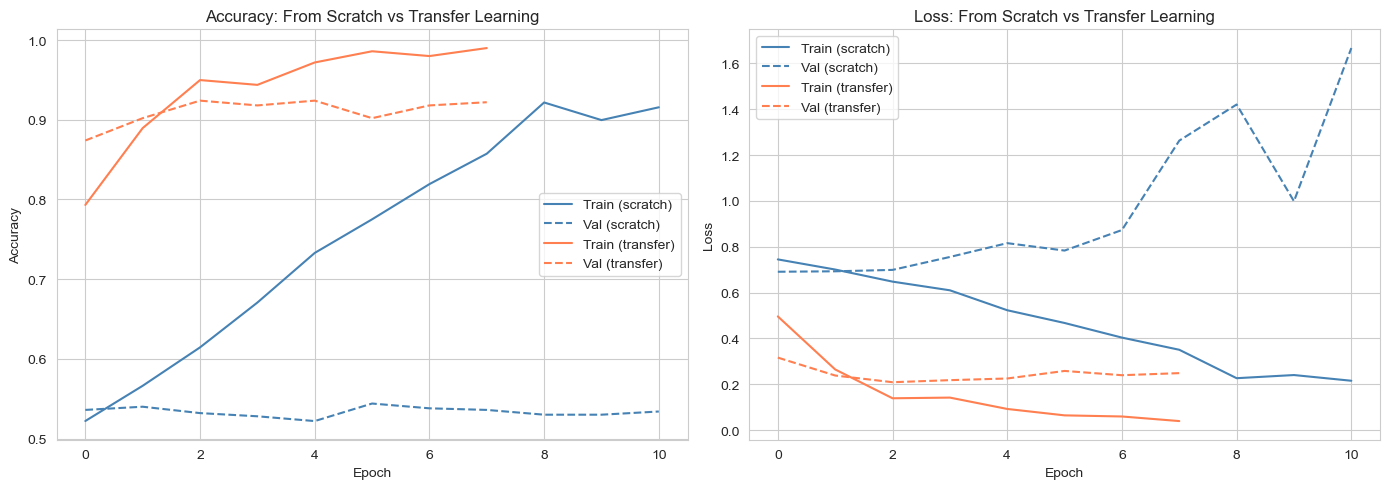

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'], label='Train (scratch)', color='steelblue')
axes[0].plot(history_scratch.history['val_accuracy'], label='Val (scratch)', color='steelblue', linestyle='--')
axes[0].plot(history_transfer.history['accuracy'], label='Train (transfer)', color='coral')
axes[0].plot(history_transfer.history['val_accuracy'], label='Val (transfer)', color='coral', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: From Scratch vs Transfer Learning')
axes[0].legend()

axes[1].plot(history_scratch.history['loss'], label='Train (scratch)', color='steelblue')
axes[1].plot(history_scratch.history['val_loss'], label='Val (scratch)', color='steelblue', linestyle='--')
axes[1].plot(history_transfer.history['loss'], label='Train (transfer)', color='coral')
axes[1].plot(history_transfer.history['val_loss'], label='Val (transfer)', color='coral', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: From Scratch vs Transfer Learning')
axes[1].legend()

plt.tight_layout()
plt.show()

In [65]:
results_hotdog.get_table()

,Train Accuracy,Test Accuracy,Gap
CNN from scratch,0.8534,0.5440,0.3094
Transfer Learning (ResNet50),0.9759,0.9240,0.0519


**Why it works:** ResNet already knows edges, textures, and shapes from ImageNet. It just needs to learn "these particular combinations of features = hot dog." That's a much simpler task than learning everything from raw pixels.

**What happened:**
- From scratch: the model struggles to learn basic visual features from ~500 images per class
- Transfer learning: fast convergence, less overfitting, much better accuracy
- We only trained ~130K parameters out of 23M+ total

## When and Why Transfer Learning Works

### Decision matrix

| | Similar to source domain | Different from source domain |
|---|---|---|
| **Large dataset** | Fine-tune all layers | Train from scratch or fine-tune carefully |
| **Small dataset** | Freeze base, train head (what we did) | Use early layers only |

### Key factors
- **Dataset size**: Small data = more freezing, large data = more fine-tuning
- **Task similarity**: The more similar your task is to the source (ImageNet), the more layers you can reuse
- **Compute budget**: Transfer learning is cheaper since you only train a fraction of the parameters

### Negative transfer

Transfer learning can **hurt** when source and target domains are too different. Features learned from natural photos (ImageNet) may not help with satellite imagery, medical X-rays, or highly stylized art.

*Question:* We used ResNet50 pre-trained on ImageNet (natural photos) for hot dog detection. Would this work well for detecting fractures in X-ray images? Why or why not?

<details>
<summary>Answer</summary>

It might still help somewhat! The early layers (edges, textures) transfer well across domains. But later layers (which detect specific object parts) would be less useful for X-rays, which have very different visual characteristics than natural photos. In practice, researchers often use ImageNet models as a starting point for medical imaging, but they fine-tune more layers and use careful augmentation.

</details>

## The Bigger Picture: Foundation Models

What we just did with ResNet50 is the **dominant paradigm** in modern AI.

### The same idea, everywhere

| Domain | Pre-train on | Fine-tune for | Example |
|---|---|---|---|
| **Vision** | ImageNet (1.2M images) | Custom classification | What we just did |
| **NLP** | Internet text (billions of words) | Specific tasks | GPT → ChatGPT |
| **Tabular** | Many datasets | New tabular tasks | TabPFN (emerging) |
| **Code** | Open-source code | Specific codebases | GitHub Copilot |

### Embeddings as transfer learning

Pre-trained models produce useful **intermediate representations** (embeddings):
- The layer just before the classification head captures rich semantic information
- These embeddings can be extracted and used for downstream tasks: similarity search, clustering, visualization
- **Connection to Class 2 (PCA):** PCA finds linear low-dimensional features. Pre-trained models find *nonlinear* features that capture much richer structure.

### The "fine-tuning era"

Most practical ML today is some form of transfer learning:
- You rarely train a model from scratch
- State-of-the-art results are achievable without massive compute budgets
- **Democratization:** Anyone with a laptop can fine-tune a powerful model
- **But also risk:** Biases in the pre-training data transfer to downstream tasks

### Coming up next week

We've seen transfer learning for images. But how does this work for **text**? How do you turn words into numbers a neural network can process?

The key ideas are **embeddings** (learned vector representations of words) and **attention** (a mechanism that lets the network decide which parts of the input to focus on — like a smarter version of convolution for sequences). These are the building blocks behind ChatGPT and other large language models. We'll explore them next week.

---

## Key Takeaways

1. **Data augmentation = free training data**, especially valuable for small datasets
2. **Transfer learning = borrowing learned features** from large pre-trained models
3. **Freeze base + train head** = the default recipe for small datasets
4. **This is the dominant paradigm in modern AI** — for images, text, and increasingly for tabular data
5. **Connection to Class 1:** Deep learning handles the curse of dimensionality by learning manifold structure; transfer learning takes it further by *reusing* that learned structure
